In [1]:
# Import necessary libraries
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib as mpl

import pandas as pd
import verde as vd
from itertools import accumulate

from tqdm import tqdm

import xarray as xr

from deap import base, creator, tools, algorithms

from CODES.dispersion_curves import compute_dispersion
from CODES.evolutionary_algorithm import process_depths,bootstrap_hof_uncertainty

from parameters_py.config import (
					MODEL_NAME,FOLDER_OUTPUT,DZ,NZ,NX,DX,SEED,MIN_FREQ,FREQ)

/home/sysop/Programs/anaconda3/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


Reading configuration file: ./config_file.cnf


# Text based on:

- Gallagher, K., & Sambridge, M. (1994). **Genetic algorithms: a powerful tool for large-scale nonlinear optimization problems**. Comput. Geosci., 20(7–8), 1229–1236.
- Fortin, F. A., Rainville, F. M., Gardner, M., Parizeau, M., and Gagné, C. **DEAP: Evolutionary Algorithms Made Easy**, Journal of Machine Learning Research, pp. 2171-2175, no 13, jul 2012.
- Haskell, N. A. ,1953, **The dispersion of surface waves on multi-layered media**, Bull. Seism. Soc. Am. 43, 17-34.
- Xia, J., Miller, R. D.,  and Park,C. B., 1999, **Estimation of near‐surface shear‐wave velocity by inversion of Rayleigh waves**, GEOPHYSICS 1999 64:3, 691-700.
- Yamanaka, H., and H. Ishida, 1996, **Application of genetic algorithms to an inversion of surface-wave dispersion data**, Bulletin of the Seismological Society of America, 86, 436–444.

# Inversion of Surface-Wave Dispersion Data

**Rayleigh-wave phase velocity is the function of four parameters (Xia et al, 1999):**
    - S-wave velocity;
    - P-wave velocity;
    - Density; and
    - Layer thickness.

In the process of retrieving a 2D Vs profile from a 3D layered earth model, the primary step involves extracting 1D Vs profiles at multiple locations across the study area. Since surface wave analysis is most sensitive to vertical variations in Vs, the lateral variations are effectively averaged out during data processing. This results in a 1D Vs model, often referred to as a layered earth model, where Vs is determined as a function of depth, while other parameters such as Vp and density (ρ) may be either included or held constant. Each 1D Vs profile is assigned to the central location of its respective receiver spread, representing the most characteristic subsurface structure at that point. By accumulating multiple such profiles, each tagged with a unique surface coordinate, a 2D Vs profile is constructed through spatial interpolation. This method enables a continuous Vs representation along a given transect while maintaining the fundamental assumption of a layered earth model.


## Ensure reproducible results by fixing seeds for numpy

In [2]:
rng = np.random.default_rng(SEED)

# Inputs and outputs

### Directory for saving model and other related stuffs: 

In [3]:
data_path = FOLDER_OUTPUT+MODEL_NAME+'/DATA/'

### Directory for saving figures: 

In [4]:
figures_path = FOLDER_OUTPUT+MODEL_NAME+'/FIGURES/'

---------

# **Comparison and final analysis:**

# Observed data

In [5]:
obs_data = pd.read_feather(data_path+'observed_data.feather')
obs_data

,survey,density,velocity_s,vpvs,depth,dispersion_curve,frequency
0,25,"[1.3861145032395439, 1.3861145032395439, 1.386...","[237.0, 237.0, 237.0, 237.0, 520.0, 520.0, 520...","[4.88, 4.88, 4.88, 4.88, 2.32, 2.32, 2.32, 2.3...","[0.0, 0.10526315789473684, 0.21052631578947367...","[715, 711, 706, 702, 698, 692, 688, 686, 686, ...","[53.33333333333333, 56.666666666666664, 59.999..."
1,35,"[1.3861145032395439, 1.3861145032395439, 1.386...","[237.0, 237.0, 237.0, 237.0, 520.0, 520.0, 520...","[4.88, 4.88, 4.88, 4.88, 2.32, 2.32, 2.32, 2.3...","[0.0, 0.10526315789473684, 0.21052631578947367...","[710, 708, 705, 701, 697, 693, 691, 689, 688, ...","[53.33333333333333, 56.666666666666664, 59.999..."
2,45,"[1.3861145032395439, 1.3861145032395439, 1.386...","[237.0, 237.0, 237.0, 237.0, 520.0, 520.0, 520...","[4.88, 4.88, 4.88, 4.88, 2.32, 2.32, 2.32, 2.3...","[0.0, 0.10526315789473684, 0.21052631578947367...","[710, 708, 704, 700, 697, 694, 692, 690, 688, ...","[53.33333333333333, 56.666666666666664, 59.999..."
3,55,"[1.3861145032395439, 1.3861145032395439, 1.386...","[237.0, 237.0, 237.0, 237.0, 520.0, 520.0, 520...","[4.88, 4.88, 4.88, 4.88, 2.32, 2.32, 2.32, 2.3...","[0.0, 0.10526315789473684, 0.21052631578947367...","[710, 708, 704, 700, 697, 694, 692, 689, 688, ...","[53.33333333333333, 56.666666666666664, 59.999..."
4,65,"[1.3861145032395439, 1.3861145032395439, 1.386...","[237.0, 237.0, 237.0, 237.0, 520.0, 520.0, 520...","[4.88, 4.88, 4.88, 4.88, 2.32, 2.32, 2.32, 2.3...","[0.0, 0.10526315789473684, 0.21052631578947367...","[710, 708, 704, 700, 697, 694, 692, 690, 688, ...","[53.33333333333333, 56.666666666666664, 59.999..."
5,75,"[1.3861145032395439, 1.3861145032395439, 1.386...","[237.0, 237.0, 237.0, 237.0, 520.0, 520.0, 520...","[4.88, 4.88, 4.88, 4.88, 2.32, 2.32, 2.32, 2.3...","[0.0, 0.10526315789473684, 0.21052631578947367...","[710, 708, 704, 700, 697, 694, 692, 690, 688, ...","[53.33333333333333, 56.666666666666664, 59.999..."
6,85,"[1.3861145032395439, 1.3861145032395439, 1.386...","[237.0, 237.0, 237.0, 237.0, 520.0, 520.0, 520...","[4.88, 4.88, 4.88, 4.88, 2.32, 2.32, 2.32, 2.3...","[0.0, 0.10526315789473684, 0.21052631578947367...","[710, 708, 704, 700, 697, 694, 692, 690, 688, ...","[53.33333333333333, 56.666666666666664, 59.999..."
7,95,"[1.3861145032395439, 1.3861145032395439, 1.386...","[237.0, 237.0, 237.0, 237.0, 520.0, 520.0, 520...","[4.88, 4.88, 4.88, 4.88, 2.32, 2.32, 2.32, 2.3...","[0.0, 0.10526315789473684, 0.21052631578947367...","[710, 707, 704, 700, 697, 694, 692, 689, 688, ...","[53.33333333333333, 56.666666666666664, 59.999..."
8,105,"[1.3861145032395439, 1.3861145032395439, 1.386...","[237.0, 237.0, 237.0, 237.0, 520.0, 520.0, 520...","[4.88, 4.88, 4.88, 4.88, 2.32, 2.32, 2.32, 2.3...","[0.0, 0.10526315789473684, 0.21052631578947367...","[710, 707, 702, 698, 696, 694, 692, 690, 688, ...","[53.33333333333333, 56.666666666666664, 59.999..."


In [6]:
obs_data.depth.shape

(9,)

In [7]:
nb_samples = obs_data.dispersion_curve[0].shape[0]
nb_samples

75

In [8]:
obs_data

,survey,density,velocity_s,vpvs,depth,dispersion_curve,frequency
0,25,"[1.3861145032395439, 1.3861145032395439, 1.386...","[237.0, 237.0, 237.0, 237.0, 520.0, 520.0, 520...","[4.88, 4.88, 4.88, 4.88, 2.32, 2.32, 2.32, 2.3...","[0.0, 0.10526315789473684, 0.21052631578947367...","[715, 711, 706, 702, 698, 692, 688, 686, 686, ...","[53.33333333333333, 56.666666666666664, 59.999..."
1,35,"[1.3861145032395439, 1.3861145032395439, 1.386...","[237.0, 237.0, 237.0, 237.0, 520.0, 520.0, 520...","[4.88, 4.88, 4.88, 4.88, 2.32, 2.32, 2.32, 2.3...","[0.0, 0.10526315789473684, 0.21052631578947367...","[710, 708, 705, 701, 697, 693, 691, 689, 688, ...","[53.33333333333333, 56.666666666666664, 59.999..."
2,45,"[1.3861145032395439, 1.3861145032395439, 1.386...","[237.0, 237.0, 237.0, 237.0, 520.0, 520.0, 520...","[4.88, 4.88, 4.88, 4.88, 2.32, 2.32, 2.32, 2.3...","[0.0, 0.10526315789473684, 0.21052631578947367...","[710, 708, 704, 700, 697, 694, 692, 690, 688, ...","[53.33333333333333, 56.666666666666664, 59.999..."
3,55,"[1.3861145032395439, 1.3861145032395439, 1.386...","[237.0, 237.0, 237.0, 237.0, 520.0, 520.0, 520...","[4.88, 4.88, 4.88, 4.88, 2.32, 2.32, 2.32, 2.3...","[0.0, 0.10526315789473684, 0.21052631578947367...","[710, 708, 704, 700, 697, 694, 692, 689, 688, ...","[53.33333333333333, 56.666666666666664, 59.999..."
4,65,"[1.3861145032395439, 1.3861145032395439, 1.386...","[237.0, 237.0, 237.0, 237.0, 520.0, 520.0, 520...","[4.88, 4.88, 4.88, 4.88, 2.32, 2.32, 2.32, 2.3...","[0.0, 0.10526315789473684, 0.21052631578947367...","[710, 708, 704, 700, 697, 694, 692, 690, 688, ...","[53.33333333333333, 56.666666666666664, 59.999..."
5,75,"[1.3861145032395439, 1.3861145032395439, 1.386...","[237.0, 237.0, 237.0, 237.0, 520.0, 520.0, 520...","[4.88, 4.88, 4.88, 4.88, 2.32, 2.32, 2.32, 2.3...","[0.0, 0.10526315789473684, 0.21052631578947367...","[710, 708, 704, 700, 697, 694, 692, 690, 688, ...","[53.33333333333333, 56.666666666666664, 59.999..."
6,85,"[1.3861145032395439, 1.3861145032395439, 1.386...","[237.0, 237.0, 237.0, 237.0, 520.0, 520.0, 520...","[4.88, 4.88, 4.88, 4.88, 2.32, 2.32, 2.32, 2.3...","[0.0, 0.10526315789473684, 0.21052631578947367...","[710, 708, 704, 700, 697, 694, 692, 690, 688, ...","[53.33333333333333, 56.666666666666664, 59.999..."
7,95,"[1.3861145032395439, 1.3861145032395439, 1.386...","[237.0, 237.0, 237.0, 237.0, 520.0, 520.0, 520...","[4.88, 4.88, 4.88, 4.88, 2.32, 2.32, 2.32, 2.3...","[0.0, 0.10526315789473684, 0.21052631578947367...","[710, 707, 704, 700, 697, 694, 692, 689, 688, ...","[53.33333333333333, 56.666666666666664, 59.999..."
8,105,"[1.3861145032395439, 1.3861145032395439, 1.386...","[237.0, 237.0, 237.0, 237.0, 520.0, 520.0, 520...","[4.88, 4.88, 4.88, 4.88, 2.32, 2.32, 2.32, 2.3...","[0.0, 0.10526315789473684, 0.21052631578947367...","[710, 707, 702, 698, 696, 694, 692, 690, 688, ...","[53.33333333333333, 56.666666666666664, 59.999..."


In [9]:
# 1. Explode todas as colunas que contêm listas ao mesmo tempo
df_exploded = obs_data.explode(['depth', 'velocity_s', 'vpvs', 'density'])

# 2. Extrai os arrays diretamente da versão "explodida" do DataFrame
obs_receptor_result_lst = (df_exploded['survey']).to_numpy(dtype=float)
obs_depth_result_lst = df_exploded['depth'].to_numpy(dtype=float)
obs_velocity_result_lst = df_exploded['velocity_s'].to_numpy(dtype=float)
obs_vpvs_result_lst = df_exploded['vpvs'].to_numpy(dtype=float)
obs_density_result_lst = df_exploded['density'].to_numpy(dtype=float)

obs_coordinates = (obs_receptor_result_lst, obs_depth_result_lst)
obs_velocitys = obs_velocity_result_lst
obs_region = (0, 100, 0, 2)
obs_shape = (9, 20)

# Inicializando o gridder
grd_obs = vd.KNeighbors(k=1).fit(obs_coordinates, obs_velocitys)

observed_grid = grd_obs.grid(
    region=obs_region,
    shape=obs_shape,
    dims=["depth", "receptor"],
    data_names="velocity",
)

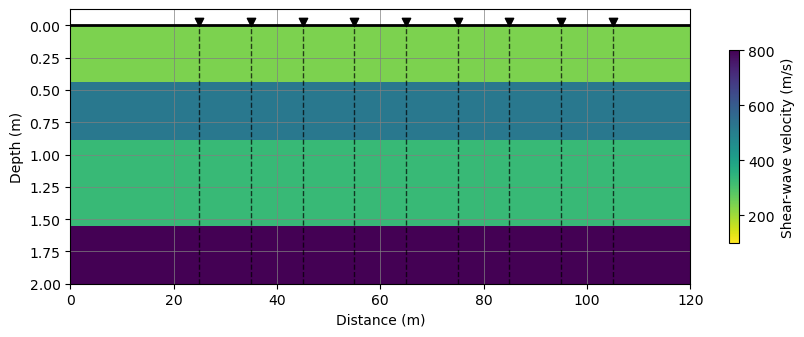

In [10]:
fig,ax = plt.subplots(1, 1, figsize=(10, 5))

im = plt.imshow(observed_grid.velocity.data, cmap='viridis_r',extent=[0, DX*NX, DZ*NZ, 0],vmin=100,vmax=800,aspect=25,origin='upper')

for idx,ix in enumerate(obs_data['survey']):
    ax.vlines(x=ix,ymin=DZ*NZ,ymax=0,colors='k',lw=1.0,ls='--',alpha=0.7)
    ax.scatter(x=ix,y=-0.025,color='k',marker='v')

ax.hlines(y=0,xmin=0,xmax=DX*NX,colors='k',lw=2,ls='-',alpha=1)
ax.set_xlabel('Distance (m)')
ax.grid(which='major', color='gray', linestyle='-', linewidth=0.5)
ax.grid(which='minor', color='gray', linestyle=':', linewidth=0.5, alpha=0.5)
ax.set_ylabel('Depth (m)')
plt.colorbar(im, ax=ax,fraction=0.15, shrink=0.5,label='Shear-wave velocity (m/s)')
fig.savefig(figures_path+'observed_slice_and_receptors.png')

# Inverted data

In [11]:
df_inversion = pd.read_feather(data_path+'inversion.feather')

In [12]:
df_inversion

,vs,thick,misfit,ngen,survey,inversion
0,"[[449.78, 331.88, 529.0, 784.65, 805.0], [449....","[[0.55, 0.41, 0.37, 0.32999999999999996, 0.34]...","[209.5344198705313, 128.84848937489608, 89.495...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",25,1
1,"[[464.72, 372.03, 419.0, 784.48, 803.0], [464....","[[0.36, 0.55, 0.31, 0.33, 0.33], [0.36, 0.55, ...","[1212.1093579500507, 132.06983960681688, 91.20...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",35,1
2,"[[419.33, 363.0, 557.89, 1023.0, 802.0], [422....","[[0.65, 0.46, 0.37, 0.42, 0.3], [0.65, 0.46, 0...","[1212.5942648677444, 129.76714830537992, 89.99...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",45,1
3,"[[418.0, 395.0, 411.0, 848.54, 808.0], [418.0,...","[[0.37, 0.61, 0.3, 0.36, 0.28], [0.37, 0.61, 0...","[204.69342682367406, 122.82637632508798, 85.81...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",55,1
4,"[[445.0, 324.0, 719.0, 871.66, 810.0], [445.0,...","[[0.64, 0.44, 0.44, 0.47, 0.35], [0.64, 0.44, ...","[212.5757306962975, 133.52005781776046, 93.231...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",65,1
5,"[[403.49, 379.47, 434.0, 901.0, 808.0], [403.4...","[[0.65, 0.32, 0.36, 0.47, 0.34], [0.65, 0.32, ...","[207.68073239543045, 1127.8556935604256, 86.95...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",75,1
6,"[[418.0, 378.0, 647.0, 815.0, 807.0], [417.16,...","[[0.54, 0.62, 0.33, 0.54, 0.39], [0.54, 0.62, ...","[212.9193338243019, 132.20743644917417, 92.077...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",85,1
7,"[[470.0, 293.0, 543.0, 886.97, 801.0], [470.0,...","[[0.5, 0.35, 0.57, 0.27, 0.34], [0.5, 0.35, 0....","[210.14363281750005, 130.79536275334652, 91.89...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",95,1
8,"[[458.0, 340.0, 544.0, 808.0, 799.0], [458.0, ...","[[0.5, 0.48, 0.35, 0.38, 0.42], [0.5, 0.48, 0....","[216.61833187726762, 135.66166583241716, 91.12...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",105,1
9,"[[447.58, 310.0, 722.0, 920.2700000000001, 807...","[[0.64, 0.41, 0.39, 0.31, 0.32], [0.64, 0.41, ...","[207.36187047592637, 128.44666195292444, 88.31...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",25,2


# Bootstrap of Hall of Fame solutions – Predicted Data

To assess parameter uncertainty, we applied a bootstrap approach to the best-performing solutions stored in the *hall of fame (HOF)* across multiple independent inversions. The HOF ensemble contains the lowest-misfit models identified by the evolutionary algorithm, representing the most probable solutions given the observed data.


- *Hall of fame (HOF)*: the best individual that ever lived in the population during the evolution. It is lexicographically sorted at all time so that the first element of the hall of fame is the individual that has the best first fitness value ever seen, according to the weights provided to the fitness at creation time.

## Methodology

#### Bootstrap Resampling:
- We resampled the HOF ensemble with replacement, randomly selecting subsets of solutions to compute statistical properties such as mean, median, and confidence intervals. This approach captures variability in the optimized parameters (vs and thickness).

#### Uncertainty and Bias Reduction:
- Bootstrapping allows estimation of parameter uncertainty without assuming a theoretical distribution, which is especially useful for nonlinear inverse problems. It also reduces bias in estimators by approximating the true sampling distribution, yielding more robust parameter estimates.

see more in [datasciencedojo](https://datasciencedojo.com/blog/bootstrap-sampling/)

![Bootstrap Scheme](https://datasciencedojo.com/wp-content/uploads/bootstrap-scheme.png)

In [13]:
# List to store the expanded data
expanded_data = []

# Iterate over each row of the original DataFrame
for _, row in df_inversion.iterrows():
    survey = row['survey']
    inversion = row['inversion']
    
    # For each inner list in Vs and thick, create a new row
    for vs_sublist, thick_sublist in zip(row['vs'], row['thick']):
        expanded_data.append({
            'vs': vs_sublist,
            'thick': thick_sublist,
            'depth': process_depths(thick_sublist),
            'survey': survey,
            'inversion': inversion})

# Create the new DataFrame
df_inversion_bootstrap = pd.DataFrame(expanded_data)

In [14]:
df_inversion_bootstrap

,vs,thick,depth,survey,inversion
0,"[449.78, 331.88, 529.0, 784.65, 805.0]","[0.55, 0.41, 0.37, 0.32999999999999996, 0.34]","[0.55, 0.96, 1.33, 1.6600000000000001, 2.0]",25,1
1,"[449.78, 330.32, 529.0, 784.65, 805.0]","[0.55, 0.41, 0.37, 0.32999999999999996, 0.2200...","[0.55, 0.96, 1.33, 1.6600000000000001, 2.0]",25,1
2,"[449.78, 330.32, 529.0, 784.65, 805.0]","[0.55, 0.41, 0.37, 0.32999999999999996, 0.34]","[0.55, 0.96, 1.33, 1.6600000000000001, 2.0]",25,1
3,"[449.78, 330.32, 529.0, 781.0, 805.0]","[0.55, 0.41, 0.37, 0.36, 0.34]","[0.55, 0.96, 1.33, 1.69, 2.0]",25,1
4,"[445.64, 335.0, 529.0, 781.0, 805.0]","[0.55, 0.41, 0.38, 0.3, 0.34]","[0.55, 0.96, 1.3399999999999999, 1.64, 2.0]",25,1
...,...,...,...,...,...
1795,"[414.0, 385.0, 432.0, 795.0, 809.0]","[0.43, 0.53, 0.35, 0.39, 0.45]","[0.43, 0.96, 1.31, 1.7000000000000002, 2.0]",105,2
1796,"[421.02, 385.0, 436.0, 796.89, 805.87]","[0.43, 0.53, 0.36, 0.41000000000000003, 0.31]","[0.43, 0.96, 1.3199999999999998, 1.73, 2.0]",105,2
1797,"[414.0, 385.0, 436.0, 795.0, 809.0]","[0.43, 0.53, 0.31, 0.39, 0.45]","[0.43, 0.96, 1.27, 1.6600000000000001, 2.0]",105,2
1798,"[423.0, 374.0, 462.0, 795.0, 809.0]","[0.59, 0.4, 0.31, 0.39, 0.45]","[0.59, 0.99, 1.3, 1.69, 2.0]",105,2


In [15]:
dic_bootstrap_results = []

for sta in  tqdm(df_inversion_bootstrap['survey'].unique(),total=len(df_inversion_bootstrap['survey'].unique()),desc='Survey', leave=True, dynamic_ncols=True,colour='green'):
    dic_bootstrap_results.append(bootstrap_hof_uncertainty(df_inversion_bootstrap[df_inversion_bootstrap['survey'] == sta],rng=rng, n_iterations=500, ci_percentiles=[2.5, 97.5]))

Survey: 100%|██████████| 9/9 [00:00<00:00, 13.69it/s]


In [16]:
df_bootstrap_results = pd.DataFrame(dic_bootstrap_results)

In [17]:
df_bootstrap_results

,survey,mean_vs,std_vs,ci_lower_vs,ci_upper_vs,bootstrap_distribution_vs,mean_depth,std_depth,ci_lower_depth,ci_upper_depth,bootstrap_distribution_depth
0,25,"[448.15007610000026, 322.5431524999991, 628.32...","[0.35431182590168203, 0.85873235745996, 6.7889...","[447.41585499999974, 320.93146124999976, 615.2...","[448.88658874999976, 324.2425174999997, 641.00...","[[447.8882999999998, 322.26734999999985, 630.3...","[0.5944357999999994, 1.004585700000001, 1.3600...","[0.003037347257065036, 0.003037930300385525, 0...","[0.5886737499999991, 0.9987975000000018, 1.355...","[0.5998762499999993, 1.0101762500000018, 1.364...","[[0.5959499999999993, 1.0061500000000019, 1.36..."
1,35,"[504.8641979000005, 314.0318881999997, 492.363...","[2.22275785604067, 4.210805675061568, 5.100271...","[500.5214050000004, 305.6466787499999, 482.668...","[509.2476775000003, 321.6196212499999, 503.665...","[[506.1964500000003, 312.36159999999995, 493.7...","[0.41612899999999936, 0.8652619999999962, 1.22...","[0.0038965701584855205, 0.003472868554955698, ...","[0.40867374999999945, 0.8582949999999967, 1.22...","[0.42380999999999935, 0.8720787499999968, 1.23...","[[0.4176999999999993, 0.8641999999999967, 1.22..."
2,45,"[430.63486449999976, 349.79462360000036, 599.1...","[0.6591218428748231, 0.7987677556167647, 4.373...","[429.37902124999977, 348.300905, 590.092822499...","[432.02571124999963, 351.34771875000007, 607.3...","[[431.42164999999966, 350.48215, 601.506499999...","[0.6107102000000004, 1.0677165000000026, 1.415...","[0.0027789577110853966, 0.003642576389041297, ...","[0.605647499999999, 1.0604187500000026, 1.4062...","[0.6164500000000002, 1.0743050000000032, 1.424...","[[0.607799999999999, 1.0692500000000025, 1.415..."
3,55,"[411.7084986999999, 390.50566969999977, 487.58...","[0.415201345317316, 0.3779808839173079, 4.9088...","[410.92766, 389.72751124999996, 478.3960074999...","[412.50858624999995, 391.20469125, 496.5935374...","[[411.3207, 390.41255000000007, 491.7149499999...","[0.47589100000000006, 1.0630093999999977, 1.38...","[0.006826076398634822, 0.005476179474779782, 0...","[0.4624237500000002, 1.052744999999997, 1.3690...","[0.4885787499999998, 1.0731287499999966, 1.394...","[[0.47955000000000003, 1.0665499999999968, 1.3..."
4,65,"[432.5844889, 350.16768689999964, 597.71682049...","[0.7607286713945801, 1.4805244016305146, 7.372...","[431.0570300000003, 347.3249325, 583.300677500...","[433.9956262500002, 353.05676375, 611.31043375...","[[433.2320500000003, 347.28955, 615.1546000000...","[0.5781545000000005, 1.0489219000000019, 1.407...","[0.003974888017290576, 0.004326826249111594, 0...","[0.5705450000000006, 1.0405975000000014, 1.397...","[0.5861787500000007, 1.0569862500000018, 1.417...","[[0.5886000000000008, 1.0605000000000024, 1.41..."
5,75,"[403.97099310000016, 382.9057161000002, 550.63...","[0.5385192899584773, 0.46029654129244457, 8.78...","[402.8998074999999, 382.06565625000013, 535.78...","[405.05161374999994, 383.8681312500001, 568.83...","[[404.2724999999997, 382.98154999999997, 547.2...","[0.642464, 1.0818532999999992, 1.4412581999999...","[0.0015106799793471028, 0.00802032817969434, 0...","[0.6393000000000004, 1.0677162499999988, 1.427...","[0.6449525000000005, 1.0984262499999986, 1.456...","[[0.6414500000000003, 1.0790499999999987, 1.43..."
6,85,"[426.77996490000015, 363.21209770000047, 564.2...","[0.8684930934112246, 1.172098287346122, 5.6396...","[425.18041500000004, 360.8218825, 552.10806125...","[428.53828625000006, 365.55353875000003, 575.1...","[[426.26565000000005, 362.9707, 566.1675500000...","[0.5105550000000016, 1.031494699999996, 1.3728...","[0.0020534617113548144, 0.009038051057058754, ...","[0.505900000000001, 1.0127974999999976, 1.3578...","[0.5143550000000012, 1.0483912499999972, 1.386...","[[0.5109500000000008, 1.0322499999999974, 1.37..."
7,95,"[444.2997800999999, 328.99208019999963, 488.06...","[1.8863373137217505, 2.6072580832107697, 3.716...","[440.68274499999995, 323.8903662499998, 481.23...","[447.98510

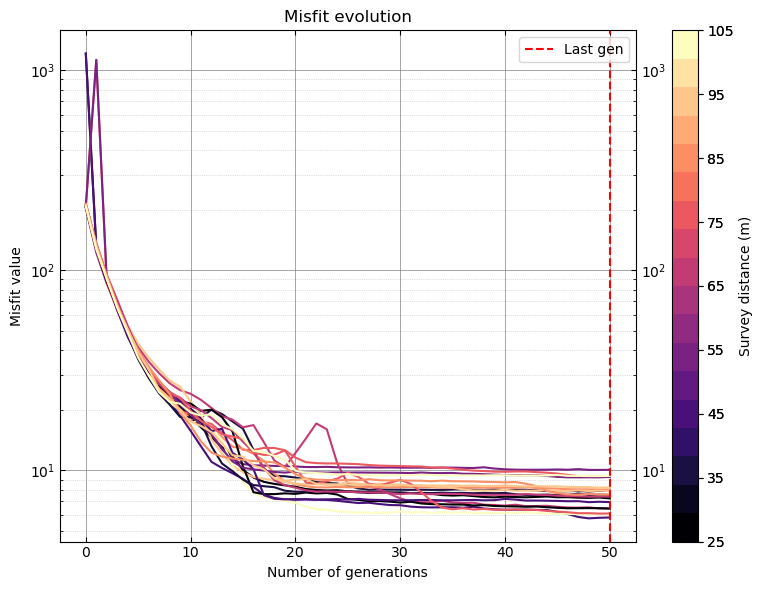

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))

# One color per survey
norm = plt.Normalize(vmin=df_inversion['survey'].values.min(), vmax=df_inversion['survey'].values.max())


cmap = plt.get_cmap('magma', len(df_inversion['survey'].values))

for dativ in df_inversion.iterrows():
    color = cmap(norm(dativ[1]['survey']))
    ax.semilogy(dativ[1]['ngen'], dativ[1]['misfit'], '-',color=color)
        
ax.set_xlabel('Number of generations')
ax.set_ylabel('Misfit value')
ax.axvline(x=len(dativ[1]['ngen'])-1, color='red', linestyle='--', label='Last gen')
ax.legend(loc='upper right')
ax.grid(True, which='both')
ax.tick_params(axis='both', which='both', direction='in',top=True, bottom=True, left=True, right=True,labelbottom=True, labeltop=False, labelleft=True,labelright=True)
ax.grid(which='major', color='gray', linestyle='-', linewidth=0.5)
ax.grid(which='minor', color='gray', linestyle=':', linewidth=0.5, alpha=0.5)
ax.set_title('Misfit evolution')

# ScalarMappable to colorbar
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Colorbar
cbar = plt.colorbar(sm, ax=ax, ticks=df_inversion['survey'].values)
cbar.set_label("Survey distance (m)")
plt.tight_layout()

fig.savefig(figures_path+MODEL_NAME+'_model_misfit_evolution.png', dpi=300)

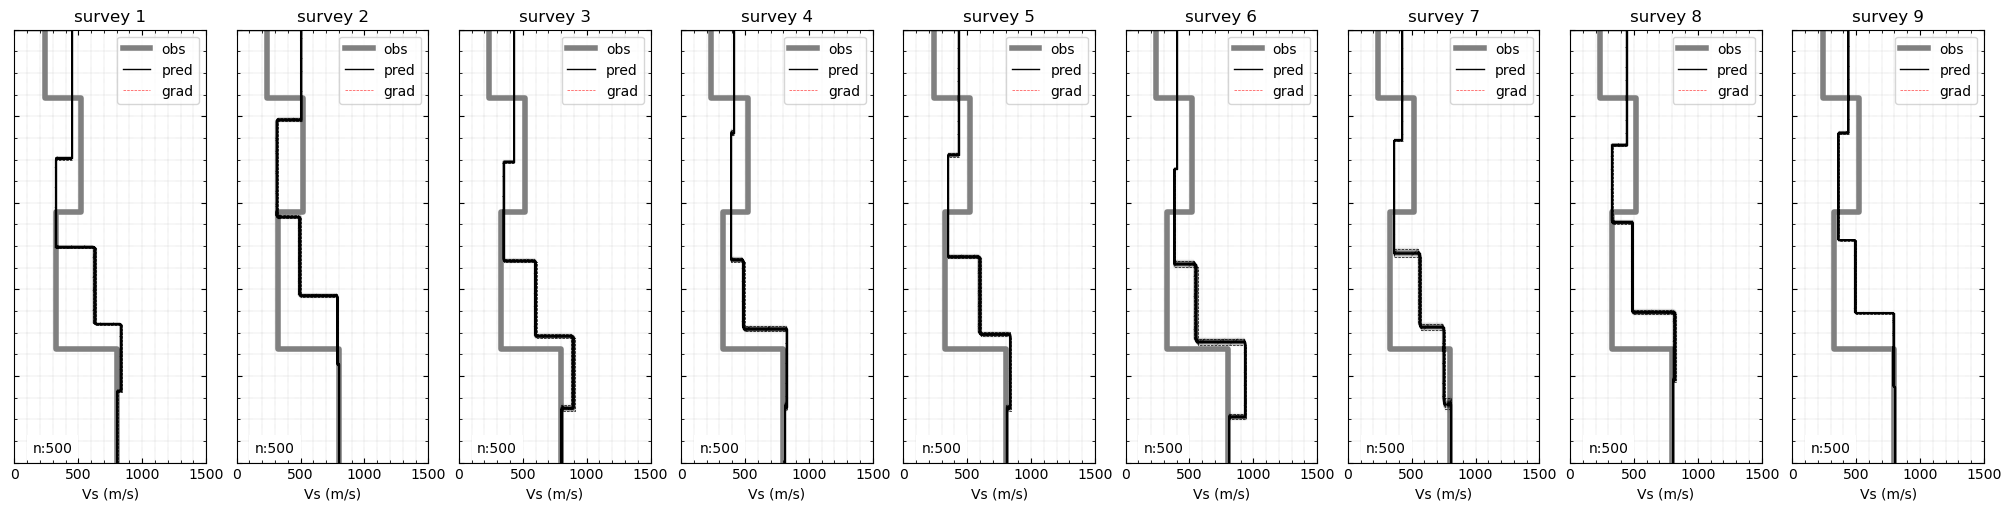

In [19]:
depth_result_lst = []
velocity_result_lst = [] 
receptor_result_lst = []

fig, axs = plt.subplots(1, obs_data.shape[0], layout="constrained",figsize=(20, 5), facecolor='white',sharey=True)

for prof_n in range(len(df_bootstrap_results)):
    
    ax = axs[prof_n]

    # --------------
    # Observed data

    observed_profile_df = obs_data.loc[prof_n]
    ax.step(observed_profile_df['velocity_s'],[dep for dep in observed_profile_df['depth']], color='gray',ls='-',lw=4,where='post',zorder=-1,label='obs')

    # --------------
    # Predicted data
    
    profile_df = df_bootstrap_results.loc[prof_n]

    # --------------
    # Gradientes (dVs/dDepth)

    depth_pred = np.insert(profile_df['mean_depth'], 0, 0)
    vs_pred    = np.insert(profile_df['mean_vs'], 0, 0)
    
    depth_obs = observed_profile_df['depth']
    vs_obs    = observed_profile_df['velocity_s']

    # ----------------
    # Plotting results
    
    ax.step(vs_pred,depth_pred, color='k',lw=1,ls='-',where='post',label='pred')
    for bootstrap_distribution_vs,bootstrap_distribution_depth in zip(profile_df['bootstrap_distribution_vs'],profile_df['bootstrap_distribution_depth']):
        bootstrap_distribution_vs = np.insert(bootstrap_distribution_vs, 0, 0)
        bootstrap_distribution_depth = np.insert(bootstrap_distribution_depth, 0, 0)
        ax.step(bootstrap_distribution_vs,bootstrap_distribution_depth, color='k',lw=0.1,ls='--',where='post',alpha=0.1)
    ax.step(profile_df['ci_lower_vs'],profile_df['ci_lower_depth'], color='k',lw=0.5,ls='--',where='post')
    ax.step(profile_df['ci_upper_vs'],profile_df['ci_upper_depth'], color='k',lw=0.5,ls='--',where='post')

    num_curves = len(profile_df['bootstrap_distribution_vs'])
    ax.text(0.2, 0.05,'n:'+f'{num_curves}', transform=ax.transAxes,ha='center', va='top', fontsize=10, color='k',bbox=dict(facecolor='white', edgecolor='none'))

    ax.plot([], [], color='r', lw=0.5,ls='--',alpha=0.75,label='grad')
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.4))
    
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(100))
    ax.xaxis.set_major_locator(ticker.MultipleLocator(500))

    ax.set_xlabel('Vs (m/s)')

    ax.set_ylim(2,0)
    ax.set_xlim(0,1500)
    ax.grid(True, which='both',color='gray', linestyle=':', linewidth=0.25)
    ax.tick_params(axis='both', which='both', direction='in',top=True, bottom=True, left=True, right=True,labelbottom=True, labeltop=False, labelleft=False,labelright=False)
    ax.set_title('survey '+str(prof_n+1))
    if prof_n == df_inversion['survey'].unique()[0]:
        ax.set_ylabel('Depth (m)')
        ax.tick_params(axis='both', which='both', direction='in',top=True, bottom=True, left=True, right=True,labelbottom=True, labeltop=False, labelleft=True,labelright=False)
    if prof_n == df_inversion['survey'].unique()[-1]:
        ax.set_ylabel('Depth (m)')
        ax.yaxis.set_label_position('right')
        ax.tick_params(axis='both', which='both', direction='in',top=True, bottom=True, left=True, right=True,labelbottom=True, labeltop=False, labelleft=False,labelright=True)
    ax.legend()
fig.savefig(figures_path+MODEL_NAME+'_observed_predicted_profiles.png')


receptor_result_lst = np.array([item for sublist in receptor_result_lst for item in sublist])
depth_result_lst = np.array([item for sublist in depth_result_lst for item in sublist])
velocity_result_lst = np.array([item for sublist in velocity_result_lst for item in sublist])
 

In [20]:
df_inversion_bootstrap

,vs,thick,depth,survey,inversion
0,"[449.78, 331.88, 529.0, 784.65, 805.0]","[0.55, 0.41, 0.37, 0.32999999999999996, 0.34]","[0.55, 0.96, 1.33, 1.6600000000000001, 2.0]",25,1
1,"[449.78, 330.32, 529.0, 784.65, 805.0]","[0.55, 0.41, 0.37, 0.32999999999999996, 0.2200...","[0.55, 0.96, 1.33, 1.6600000000000001, 2.0]",25,1
2,"[449.78, 330.32, 529.0, 784.65, 805.0]","[0.55, 0.41, 0.37, 0.32999999999999996, 0.34]","[0.55, 0.96, 1.33, 1.6600000000000001, 2.0]",25,1
3,"[449.78, 330.32, 529.0, 781.0, 805.0]","[0.55, 0.41, 0.37, 0.36, 0.34]","[0.55, 0.96, 1.33, 1.69, 2.0]",25,1
4,"[445.64, 335.0, 529.0, 781.0, 805.0]","[0.55, 0.41, 0.38, 0.3, 0.34]","[0.55, 0.96, 1.3399999999999999, 1.64, 2.0]",25,1
...,...,...,...,...,...
1795,"[414.0, 385.0, 432.0, 795.0, 809.0]","[0.43, 0.53, 0.35, 0.39, 0.45]","[0.43, 0.96, 1.31, 1.7000000000000002, 2.0]",105,2
1796,"[421.02, 385.0, 436.0, 796.89, 805.87]","[0.43, 0.53, 0.36, 0.41000000000000003, 0.31]","[0.43, 0.96, 1.3199999999999998, 1.73, 2.0]",105,2
1797,"[414.0, 385.0, 436.0, 795.0, 809.0]","[0.43, 0.53, 0.31, 0.39, 0.45]","[0.43, 0.96, 1.27, 1.6600000000000001, 2.0]",105,2
1798,"[423.0, 374.0, 462.0, 795.0, 809.0]","[0.59, 0.4, 0.31, 0.39, 0.45]","[0.59, 0.99, 1.3, 1.69, 2.0]",105,2


In [21]:
df_inversion_bootstrap[['simulated_dispersion', 'simulated_frequency']] = (df_inversion_bootstrap.apply(compute_dispersion,axis=1,vs_col='vs',depth_col='thick',min_freq=MIN_FREQ,max_freq=FREQ*3,number_samples=nb_samples))

In [22]:
df_inversion_bootstrap

,vs,thick,depth,survey,inversion,simulated_dispersion,simulated_frequency
0,"[449.78, 331.88, 529.0, 784.65, 805.0]","[0.55, 0.41, 0.37, 0.32999999999999996, 0.34]","[0.55, 0.96, 1.33, 1.6600000000000001, 2.0]",25,1,"[713.6897026589731, 711.865972190223, 710.0461...","[50.0, 53.37837837837838, 56.756756756756765, ..."
1,"[449.78, 330.32, 529.0, 784.65, 805.0]","[0.55, 0.41, 0.37, 0.32999999999999996, 0.2200...","[0.55, 0.96, 1.33, 1.6600000000000001, 2.0]",25,1,"[713.6792856825108, 711.8526255262608, 710.028...","[50.0, 53.37837837837838, 56.756756756756765, ..."
2,"[449.78, 330.32, 529.0, 784.65, 805.0]","[0.55, 0.41, 0.37, 0.32999999999999996, 0.34]","[0.55, 0.96, 1.33, 1.6600000000000001, 2.0]",25,1,"[713.6792856825108, 711.8526255262608, 710.028...","[50.0, 53.37837837837838, 56.756756756756765, ..."
3,"[449.78, 330.32, 529.0, 781.0, 805.0]","[0.55, 0.41, 0.37, 0.36, 0.34]","[0.55, 0.96, 1.33, 1.69, 2.0]",25,1,"[713.6216684950107, 711.7881724012606, 709.957...","[50.0, 53.37837837837838, 56.756756756756765, ..."
4,"[445.64, 335.0, 529.0, 781.0, 805.0]","[0.55, 0.41, 0.38, 0.3, 0.34]","[0.55, 0.96, 1.3399999999999999, 1.64, 2.0]",25,1,"[713.2159077056444, 711.4019428618944, 709.597...","[50.0, 53.37837837837838, 56.756756756756765, ..."
...,...,...,...,...,...,...,...
1795,"[414.0, 385.0, 432.0, 795.0, 809.0]","[0.43, 0.53, 0.35, 0.39, 0.45]","[0.43, 0.96, 1.31, 1.7000000000000002, 2.0]",105,2,"[714.3843704928681, 712.461030649118, 710.5718...","[50.0, 53.37837837837838, 56.756756756756765, ..."
1796,"[421.02, 385.0, 436.0, 796.89, 805.87]","[0.43, 0.53, 0.36, 0.41000000000000003, 0.31]","[0.43, 0.96, 1.3199999999999998, 1.73, 2.0]",105,2,"[712.0455033053678, 710.1319290866176, 708.243...","[50.0, 53.37837837837838, 56.756756756756765, ..."
1797,"[414.0, 385.0, 436.0, 795.0, 809.0]","[0.43, 0.53, 0.31, 0.39, 0.45]","[0.43, 0.96, 1.27, 1.6600000000000001, 2.0]",105,2,"[715.2054154147435, 713.3152786959935, 711.466...","[50.0, 53.37837837837838, 56.756756756756765, ..."
1798,"[423.0, 374.0, 462.0, 795.0, 809.0]","[0.59, 0.4, 0.31, 0.39, 0.45]","[0.59, 0.99, 1.3, 1.69, 2.0]",105,2,"[715.2094864140548, 713.3144668828047, 711.445...","[50.0, 53.37837837837838, 56.756756756756765, ..."


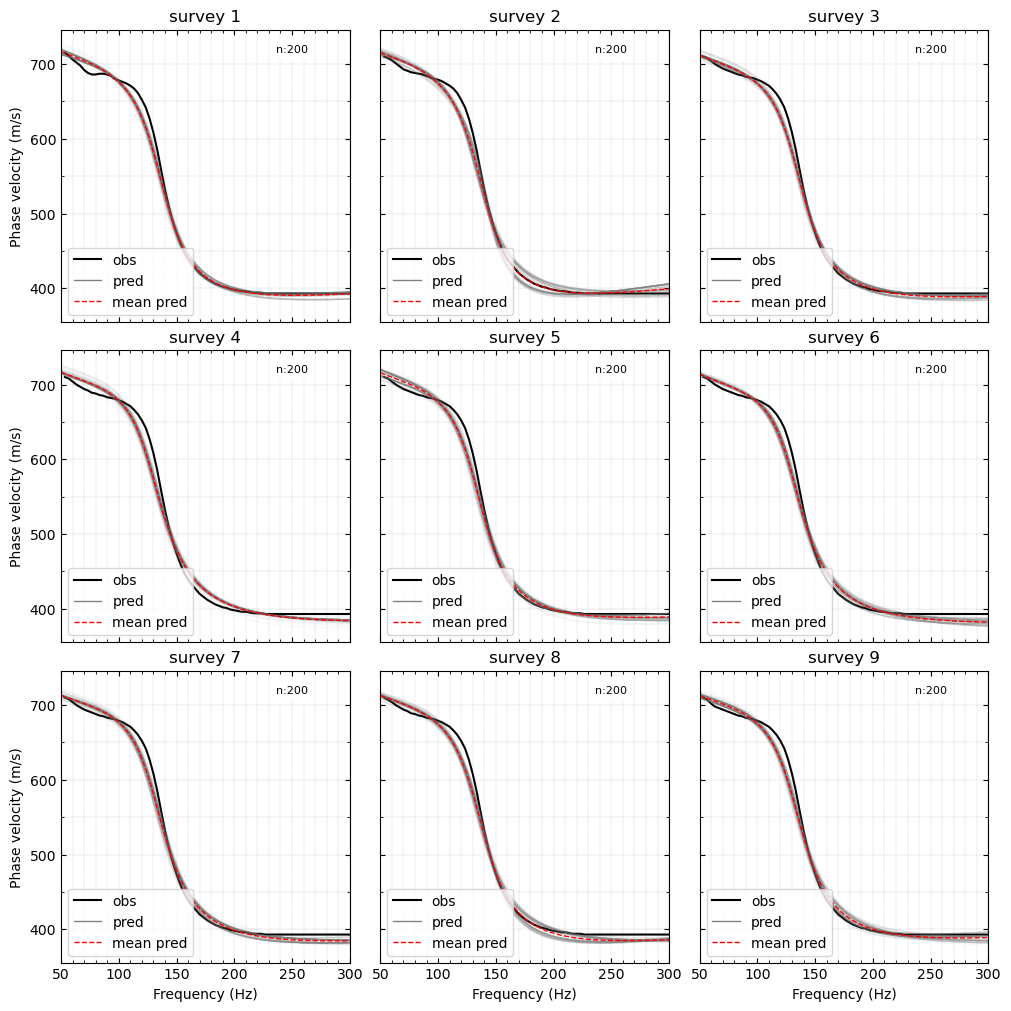

In [23]:
fig, axs = plt.subplots(3, 3, layout="constrained", figsize=(10, 10), facecolor='white', sharey=True)
axs = axs.flatten()

for idx,prof_n in enumerate(df_bootstrap_results.survey.unique()):
    
    ax = axs[idx]

    # --------------
    # Observed data
    observed_profile_df = obs_data[obs_data['survey'] == prof_n].iloc[0]
    ax.plot(observed_profile_df['frequency'], observed_profile_df['dispersion_curve'], c='k', ls='-', label='obs')

    # --------------
    # Predicted data
    profile_df = df_inversion_bootstrap[df_inversion_bootstrap['survey'] == prof_n]
    mean_simulated_frequency = profile_df['simulated_frequency'].mean()
    mean_simulated_dispersion = profile_df['simulated_dispersion'].mean()

    for simulated_frequency, simulated_dispersion in zip(profile_df['simulated_frequency'], profile_df['simulated_dispersion']):
        ax.plot(simulated_frequency, simulated_dispersion, c='grey', ls='-', alpha=0.025, lw=1)
        
    ax.plot([], [], c='grey', ls='-', lw=1, label='pred')
    ax.plot(mean_simulated_frequency, mean_simulated_dispersion, c='r', ls='--', lw=1, label='mean pred')

    num_curves = len(profile_df['thick'])
    ax.text(0.8, 0.95, 'n:' + f'{num_curves}', transform=ax.transAxes,
            ha='center', va='top', fontsize=8, color='k',
            bbox=dict(facecolor='white', edgecolor='none'))

    ax.yaxis.set_minor_locator(ticker.MultipleLocator(50))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(100))
    
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(10))
    ax.xaxis.set_major_locator(ticker.MultipleLocator(50))

    ax.set_xlim(MIN_FREQ, FREQ * 3)

    ax.grid(True, which='both', color='gray', linestyle=':', linewidth=0.25)
    ax.set_title('survey ' + str(idx+1))

    row = idx // 3
    col = idx % 3

    ax.tick_params(axis='both', which='both', direction='in', top=True, bottom=True, left=True, right=True, 
                   labeltop=False, labelright=False, labelbottom=False, labelleft=False)

    if col == 0:
        ax.set_ylabel('Phase velocity (m/s)')
        ax.tick_params(labelleft=True)

    if row == 2:
        ax.set_xlabel('Frequency (Hz)')
        ax.tick_params(labelbottom=True)
        
    ax.legend(loc='lower left')

fig.savefig(figures_path + MODEL_NAME + '_observed_predicted_dispersion_curves.png')

In [24]:
df_bootstrap_results

,survey,mean_vs,std_vs,ci_lower_vs,ci_upper_vs,bootstrap_distribution_vs,mean_depth,std_depth,ci_lower_depth,ci_upper_depth,bootstrap_distribution_depth
0,25,"[448.15007610000026, 322.5431524999991, 628.32...","[0.35431182590168203, 0.85873235745996, 6.7889...","[447.41585499999974, 320.93146124999976, 615.2...","[448.88658874999976, 324.2425174999997, 641.00...","[[447.8882999999998, 322.26734999999985, 630.3...","[0.5944357999999994, 1.004585700000001, 1.3600...","[0.003037347257065036, 0.003037930300385525, 0...","[0.5886737499999991, 0.9987975000000018, 1.355...","[0.5998762499999993, 1.0101762500000018, 1.364...","[[0.5959499999999993, 1.0061500000000019, 1.36..."
1,35,"[504.8641979000005, 314.0318881999997, 492.363...","[2.22275785604067, 4.210805675061568, 5.100271...","[500.5214050000004, 305.6466787499999, 482.668...","[509.2476775000003, 321.6196212499999, 503.665...","[[506.1964500000003, 312.36159999999995, 493.7...","[0.41612899999999936, 0.8652619999999962, 1.22...","[0.0038965701584855205, 0.003472868554955698, ...","[0.40867374999999945, 0.8582949999999967, 1.22...","[0.42380999999999935, 0.8720787499999968, 1.23...","[[0.4176999999999993, 0.8641999999999967, 1.22..."
2,45,"[430.63486449999976, 349.79462360000036, 599.1...","[0.6591218428748231, 0.7987677556167647, 4.373...","[429.37902124999977, 348.300905, 590.092822499...","[432.02571124999963, 351.34771875000007, 607.3...","[[431.42164999999966, 350.48215, 601.506499999...","[0.6107102000000004, 1.0677165000000026, 1.415...","[0.0027789577110853966, 0.003642576389041297, ...","[0.605647499999999, 1.0604187500000026, 1.4062...","[0.6164500000000002, 1.0743050000000032, 1.424...","[[0.607799999999999, 1.0692500000000025, 1.415..."
3,55,"[411.7084986999999, 390.50566969999977, 487.58...","[0.415201345317316, 0.3779808839173079, 4.9088...","[410.92766, 389.72751124999996, 478.3960074999...","[412.50858624999995, 391.20469125, 496.5935374...","[[411.3207, 390.41255000000007, 491.7149499999...","[0.47589100000000006, 1.0630093999999977, 1.38...","[0.006826076398634822, 0.005476179474779782, 0...","[0.4624237500000002, 1.052744999999997, 1.3690...","[0.4885787499999998, 1.0731287499999966, 1.394...","[[0.47955000000000003, 1.0665499999999968, 1.3..."
4,65,"[432.5844889, 350.16768689999964, 597.71682049...","[0.7607286713945801, 1.4805244016305146, 7.372...","[431.0570300000003, 347.3249325, 583.300677500...","[433.9956262500002, 353.05676375, 611.31043375...","[[433.2320500000003, 347.28955, 615.1546000000...","[0.5781545000000005, 1.0489219000000019, 1.407...","[0.003974888017290576, 0.004326826249111594, 0...","[0.5705450000000006, 1.0405975000000014, 1.397...","[0.5861787500000007, 1.0569862500000018, 1.417...","[[0.5886000000000008, 1.0605000000000024, 1.41..."
5,75,"[403.97099310000016, 382.9057161000002, 550.63...","[0.5385192899584773, 0.46029654129244457, 8.78...","[402.8998074999999, 382.06565625000013, 535.78...","[405.05161374999994, 383.8681312500001, 568.83...","[[404.2724999999997, 382.98154999999997, 547.2...","[0.642464, 1.0818532999999992, 1.4412581999999...","[0.0015106799793471028, 0.00802032817969434, 0...","[0.6393000000000004, 1.0677162499999988, 1.427...","[0.6449525000000005, 1.0984262499999986, 1.456...","[[0.6414500000000003, 1.0790499999999987, 1.43..."
6,85,"[426.77996490000015, 363.21209770000047, 564.2...","[0.8684930934112246, 1.172098287346122, 5.6396...","[425.18041500000004, 360.8218825, 552.10806125...","[428.53828625000006, 365.55353875000003, 575.1...","[[426.26565000000005, 362.9707, 566.1675500000...","[0.5105550000000016, 1.031494699999996, 1.3728...","[0.0020534617113548144, 0.009038051057058754, ...","[0.505900000000001, 1.0127974999999976, 1.3578...","[0.5143550000000012, 1.0483912499999972, 1.386...","[[0.5109500000000008, 1.0322499999999974, 1.37..."
7,95,"[444.2997800999999, 328.99208019999963, 488.06...","[1.8863373137217505, 2.6072580832107697, 3.716...","[440.68274499999995, 323.8903662499998, 481.23...","[447.98510

In [25]:
# 1. Explode todas as colunas que contêm listas ao mesmo tempo
df_exploded = obs_data.explode(['depth', 'velocity_s', 'vpvs', 'density'])

# 2. Extrai os arrays diretamente da versão "explodida" do DataFrame
obs_receptor_result_lst = (df_exploded['survey']).to_numpy(dtype=float)
obs_depth_result_lst = df_exploded['depth'].to_numpy(dtype=float)
obs_velocity_result_lst = df_exploded['velocity_s'].to_numpy(dtype=float)
obs_vpvs_result_lst = df_exploded['vpvs'].to_numpy(dtype=float)
obs_density_result_lst = df_exploded['density'].to_numpy(dtype=float)

obs_coordinates = (obs_receptor_result_lst, obs_depth_result_lst)
obs_velocitys = obs_velocity_result_lst
obs_region = (0, 100, 0, 2)
obs_shape = (9, 20)

# Inicializando o gridder
grd_obs = vd.KNeighbors(k=1).fit(obs_coordinates, obs_velocitys)

observed_grid = grd_obs.grid(
    region=obs_region,
    shape=obs_shape,
    dims=["depth", "receptor"],
    data_names="velocity",
)

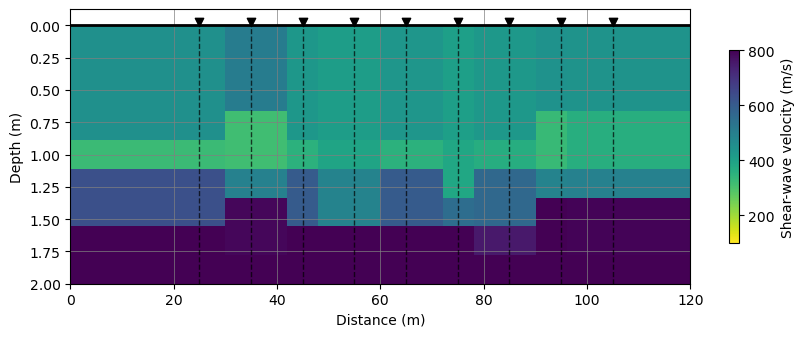

In [26]:
# GRID

velocity_result_lst = [i for i in df_bootstrap_results['mean_vs'].values]
receptor_result_lst =  [[int(i)]*len(j) for i,j in zip(df_bootstrap_results['survey'].values,df_bootstrap_results['mean_vs'].values)]
depth_result_lst  = [i for i in df_bootstrap_results['mean_depth'].values]

receptor_result_lst = np.array([item for sublist in receptor_result_lst for item in sublist])
depth_result_lst = np.array([item for sublist in depth_result_lst for item in sublist])
velocity_result_lst = np.array([item for sublist in velocity_result_lst for item in sublist])

# ----------
# Input data

coordinates = (receptor_result_lst, depth_result_lst)
velocitys = velocity_result_lst
region = (0,NX*DX,0,NZ*DZ)
    
shape = (9,20)
    
# Now we can set up a gridder for the decimated data
grd_predic = vd.KNeighbors().fit(coordinates, velocitys)
    
# The 'grid' method can still make a geographic grid if we pass in a projection
predicted_grid = grd_predic.grid(region=region,shape=shape,dims=["depth","receptor"],data_names="velocity")
# plotting 
fig,ax = plt.subplots(1, 1, figsize=(10, 5))

im = plt.imshow(predicted_grid.velocity.data, cmap='viridis_r',extent=[0, NX*DX, NZ*DZ, 0],vmin=100,vmax=800,aspect=25,origin='upper')

lst_receptor = list(set(receptor_result_lst))
for ix in lst_receptor:
    ax.vlines(x=ix,ymin=NZ*DZ,ymax=0,colors='k',lw=1.0,ls='--',alpha=0.7)
    ax.scatter(x=ix,y=-0.025,color='k',marker='v')

ax.hlines(y=0,xmin=0,xmax=NX*DX,colors='k',lw=2,ls='-',alpha=1)
ax.set_xlabel('Distance (m)')
ax.grid(which='major', color='gray', linestyle='-', linewidth=0.5)
ax.grid(which='minor', color='gray', linestyle=':', linewidth=0.5, alpha=0.5)
ax.set_ylabel('Depth (m)')
plt.colorbar(im, ax=ax,fraction=0.15, shrink=0.5,label='Shear-wave velocity (m/s)')
fig.savefig(figures_path+MODEL_NAME+'_inversion_slice_and_receptors.png')

# Error

In [27]:
deviation_grid = observed_grid - predicted_grid

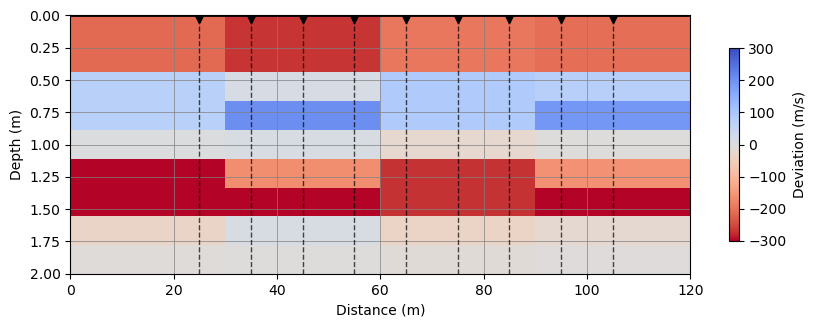

In [28]:
fig,ax = plt.subplots(1, 1, figsize=(10, 5))

im = plt.imshow(deviation_grid.velocity.data, cmap='coolwarm_r',extent=[0, NX*DX, NZ*DZ, 0],vmin=-300,vmax=300,aspect=25,origin='upper')

for idx,ix in enumerate(lst_receptor):
    ax.vlines(x=ix,ymin=NZ*DZ,ymax=0,colors='k',lw=1.0,ls='--',alpha=0.7)
    ax.scatter(x=ix,y=0.025,color='k',marker='v')

ax.hlines(y=0,xmin=0,xmax=NX*DX,colors='k',lw=2,ls='-',alpha=1)
ax.set_xlabel('Distance (m)')
ax.grid(which='major', color='gray', linestyle='-', linewidth=0.5)
ax.grid(which='minor', color='gray', linestyle=':', linewidth=0.5, alpha=0.5)
ax.set_ylabel('Depth (m)')
plt.colorbar(im, ax=ax,fraction=0.15, shrink=0.5,label='Deviation (m/s)')
fig.savefig(figures_path+MODEL_NAME+'_deviation_observed_predicted_receptors.png')